In [18]:
import pandas as pd

resumes = pd.read_csv(r"C:\Users\Atul\Desktop\JOB ML\Resume.csv")
jobs = pd.read_csv(r"C:\Users\Atul\Desktop\JOB ML\job_title_des.csv")

print("Resumes Dataset:")
print(resumes.head())

print("\nJobs Dataset:")
print(jobs.head())


Resumes Dataset:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

Jobs Dataset:
   Unnamed: 0             Job Title  \
0           0     Flutter Developer   
1           1      Django Developer   
2           2      Machine Learning   
3           3         iOS Devel

In [ ]:
print("Resumes Dataset Info:")
print(resumes.info())

print("\nJobs Dataset Info:")
print(jobs.info())



Resumes Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

Jobs Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       2277 non-null   int64 
 1   Job Title        2277 non-null   object
 2   Job Description  2277 non-null   object
dtypes: int64(1), object(2)
memory usage: 53.5+ KB
None


In [ ]:
print("Missing values in Resumes:")
print(resumes.isnull().sum())

print("\nMissing values in Jobs:")
print(jobs.isnull().sum())


Missing values in Resumes:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Missing values in Jobs:
Unnamed: 0         0
Job Title          0
Job Description    0
dtype: int64


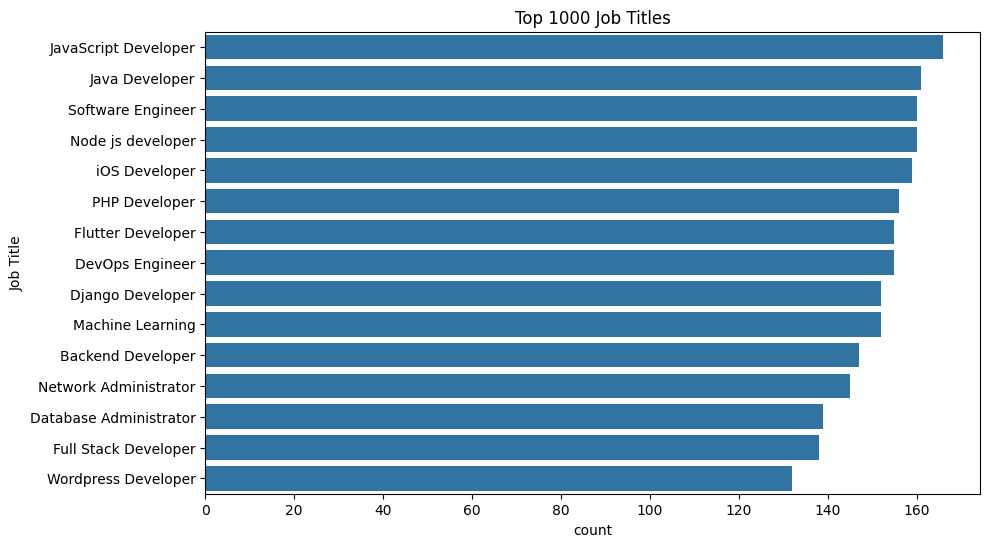

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(y='Job Title', data=jobs, order=jobs['Job Title'].value_counts().index[:1000])

plt.title("Top 1000 Job Titles")
plt.show()


In [25]:
resumes['resume_length'] = resumes['Resume_str'].apply(lambda x: len(str(x).split()))
jobs['job_desc_length'] = jobs['Job Description'].apply(lambda x: len(str(x).split()))

print("Resume text length stats:")
print(resumes['resume_length'].describe())

print("\nJob description text length stats:")
print(jobs['job_desc_length'].describe())


Resume text length stats:
count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: resume_length, dtype: float64

Job description text length stats:
count    2277.000000
mean      276.201581
std       201.828979
min        12.000000
25%       130.000000
50%       223.000000
75%       372.000000
max      1575.000000
Name: job_desc_length, dtype: float64


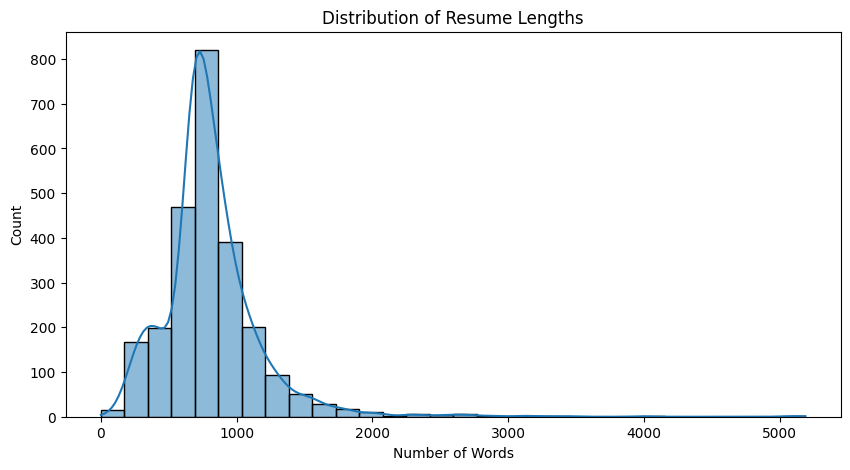

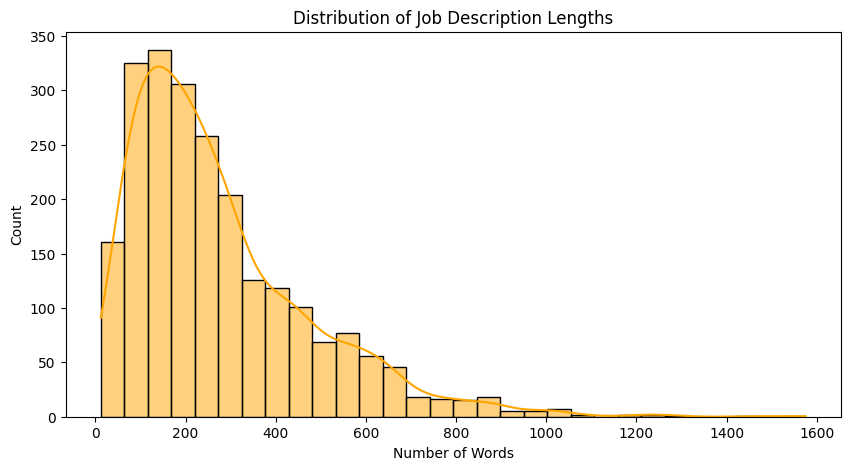

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(resumes['resume_length'], bins=30, kde=True)
plt.title("Distribution of Resume Lengths")
plt.xlabel("Number of Words")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(jobs['job_desc_length'], bins=30, kde=True, color='orange')
plt.title("Distribution of Job Description Lengths")
plt.xlabel("Number of Words")
plt.show()



In [30]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')


c:\Users\Atul\Desktop\JOB ML\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Atul\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to 

In [ ]:
resume_texts = resumes['Resume_str'].astype(str).tolist()
resume_embeddings = model.encode(resume_texts, show_progress_bar=True)

job_texts = jobs['Job Description'].astype(str).tolist()
job_embeddings = model.encode(job_texts, show_progress_bar=True)

print("Resume embeddings shape:", resume_embeddings.shape)
print("Job embeddings shape:", job_embeddings.shape)



Batches: 100%|██████████| 72/72 [01:18<00:00,  1.10s/it]

Resume embeddings shape: (2484, 384)
Job embeddings shape: (2277, 384)


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(resume_embeddings, job_embeddings)

print("Similarity matrix shape:", similarity_matrix.shape)


Similarity matrix shape: (2484, 2277)


In [34]:
top_k = 3  

recommendations = []

for i, row in enumerate(similarity_matrix):
    top_jobs_idx = row.argsort()[-top_k:][::-1]  
    recommended_jobs = jobs.iloc[top_jobs_idx]['Job Title'].tolist()
    recommendations.append(recommended_jobs)

resumes['Top_Jobs'] = recommendations

resumes[['Resume_str', 'Top_Jobs']].head()


,Resume_str,Top_Jobs
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"[Database Administrator, Database Administrato..."
1,"HR SPECIALIST, US HR OPERATIONS ...","[Database Administrator, Database Administrato..."
2,HR DIRECTOR Summary Over 2...,"[Database Administrator, Database Administrato..."
3,HR SPECIALIST Summary Dedica...,"[Database Administrator, Database Administrato..."
4,HR MANAGER Skill Highlights ...,"[Database Administrator, Database Administrato..."
